In [11]:
import tensorflow as tf
from keras import layers, models
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

from src.data.freihand import FreiHand

In [12]:
dataset = FreiHand()
dataset.validate()

train_idx, val_idx = dataset.train_validation_split(validation_fraction=0.1)

train_ds = dataset.tf_dataset(
    indices=train_idx[:5000],   # start lite!
    batch_size=16,
    image_size=(128, 128),
    shuffle=True,
    flatten_keypoints=True
)

val_ds = dataset.tf_dataset(
    indices=val_idx[:1000],
    batch_size=16,
    image_size=(128, 128),
    flatten_keypoints=True
)

In [13]:
model = models.Sequential([
  layers.Input(shape=(128,128,3)),

  layers.Conv2D(32, (3,3), padding="same", activation="relu"),
  layers.BatchNormalization(),
  layers.Conv2D(32, (3,3), padding="same", activation="relu"),
  layers.MaxPooling2D(),

  layers.Conv2D(64, (3,3), padding="same", activation="relu"),
  layers.BatchNormalization(),
  layers.Conv2D(64, (3,3), padding="same", activation="relu"),
  layers.MaxPooling2D(),

  layers.Conv2D(128, (3,3), padding="same", activation="relu"),
  layers.MaxPooling2D(),

  layers.Flatten(),
  layers.Dense(128, activation="relu"),
  layers.Dropout(0.5),
  layers.Dense(42)
])

In [14]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [15]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mse",
    metrics=["mae"]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 232ms/step - loss: 790.7599 - mae: 21.9585 - val_loss: 1138.9531 - val_mae: 31.3527
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 77s 240ms/step - loss: 387.6036 - mae: 15.7208 - val_loss: 233.7966 - val_mae: 12.5164
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 248ms/step - loss: 322.7378 - mae: 14.3326 - val_loss: 139.2193 - val_mae: 9.5971
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 203ms/step - loss: 289.5831 - mae: 13.5886 - val_loss: 124.4383 - val_mae: 8.9358
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 214ms/step - loss: 268.6052 - mae: 13.0764 - val_loss: 128.6564 - val_mae: 9.0855
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 225ms/step - loss: 258.3203 - mae: 12.7833 - val_loss: 113.5845 - val_mae: 8.5169
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 202ms/step - loss: 246.1538 - mae: 12.4992 - val_loss: 139.7876 - val_mae: 9.3717
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 204ms/step - loss: 241.1446 - mae: 12.3490 - val_loss: 110.9158 - val_m

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step


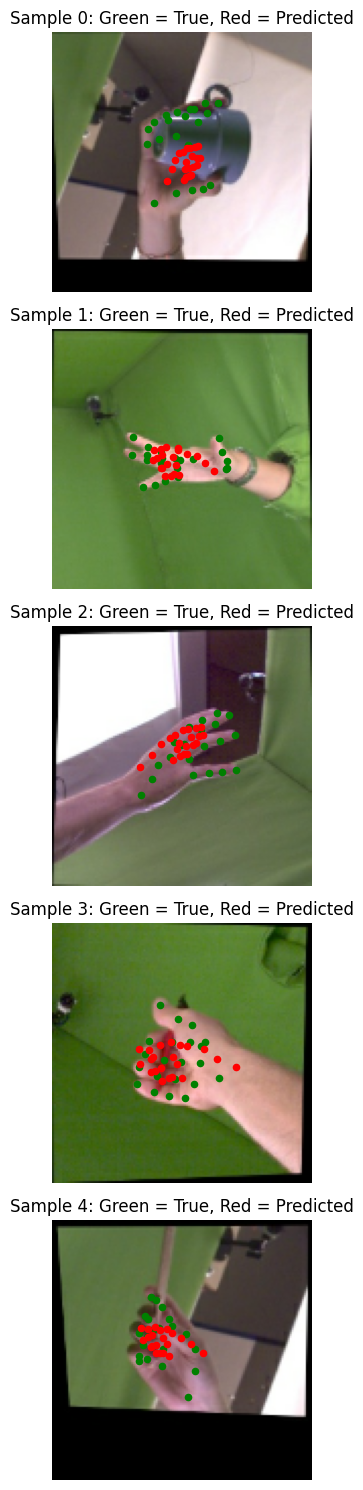

In [8]:
for images, keypoints in val_ds.take(1):
    break

preds = model.predict(images)

import matplotlib.pyplot as plt

num_samples = 5
plt.figure(figsize=(15, 3 * num_samples))

for i in range(num_samples):
    img = images[i].numpy()
    true_kp = keypoints[i].numpy().reshape(21, 2)
    pred_kp = preds[i].reshape(21, 2)

    plt.subplot(num_samples, 1, i+1)
    plt.imshow(img)

    # ekte keypoints (grønn)
    for x, y in true_kp:
        plt.scatter(x, y, c="green", s=20)

    # predikerte keypoints (rød)
    for x, y in pred_kp:
        plt.scatter(x, y, c="red", s=20)
    
    plt.title(f"Sample {i}: Green = True, Red = Predicted")
    plt.axis("off")

plt.tight_layout()
plt.show()